# 01 — ARIMA / ARIMAX Baseline

Auto-select the ARIMA order, run a both-window (expanding + rolling) ablation ladder of ARIMAX variants over
public-information groups, pick the best by RMSE and WDA, then stress-test the efficiency null
with Diebold-Mariano (vs the drift floor), ex-2025 robustness, and Pesaran-Timmermann.

### Roadmap

| § | Step | What happens |
|---|---|---|
| 1 | Load features | Read **only** the silver target (+ `split`) from `features_weekly.csv`; build the train+val refit sample. The exogenous columns are read later in §4, where the ladder uses them (pure ARIMA needs none). |
| 2 | Order selection (AIC) | Grid-search $(p,0,q)$ on train+val. AIC picks $(0,0,0)$ — weekly silver returns have no usable linear autocorrelation, so ARIMAX reduces to OLS on lagged regressors. |
| 3 | Forecast schemes + walk-forward | `recursive_forecast` (expanding) and `rolling_forecast` (last 100w), both refit every step. Run pure **ARIMA** with each window — the weak-form baseline; §3.1 plots expanding (= drift) vs rolling. |
| 4 | Ablation ladder | ARIMAX ladder run in **both windows** (expanding + rolling): rung 0 = 6 cross-asset returns, then each public-info group (GS / FRED-daily / COT / sentiment / …) + the BestLag filter rungs. |
| 5 | Evaluate | One table — RMSE / MAE / OOS R² / DA / WDA for Naïve, Drift, ARIMA (both windows), every ARIMAX rung. Save `metrics_arima.csv`. |
| 6 | Sub-period robustness | Pick the best ARIMAX by **RMSE** (primary, magnitude) and **WDA** (secondary, directional); break both down by `PERIODS`; save period + preds CSVs (WDA-best under legacy names, RMSE-best alongside). |
| 7 | Predicted vs actual | Full-window plot, **two panels**: WDA-best (directional pick) and RMSE-best (magnitude pick). |
| 8 | Significance tests | Load-bearing **DM vs-Drift floor** (OOS R² + DM, squared & absolute error). 8b: Pesaran–Timmermann directional lens. 8c: ex-2025 robustness (full battery). |
| 9 | 2026 zoom | Actual vs best variants on the 2026 YTD slice — two panels (WDA-best, RMSE-best), drift overlaid. |
| 9b | Coefficient inspection | In-sample ARIMAX coefficient tables for the selected variants — descriptive interpretability, not a discovery claim. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

## 1. Load the silver target

In [2]:
# ARIMA needs only the silver target, so read just that column (+ the split labels). The
# exogenous columns are read later in §4, where the ablation ladder actually uses them.
TARGET = 'silver_return'
silver = pd.read_csv('../../../data/processed/features_weekly.csv',
                     index_col='week_end', parse_dates=True, usecols=['week_end', 'split', TARGET])

# Weekly target per split (already W-FRI-summed in the frame).
def _y(name): return silver.loc[silver['split'] == name, TARGET].dropna()
y_train, y_val, y_test = _y('train'), _y('val'), _y('test')
# Refit on train+val before predicting test (val already used for AIC selection),
# so walk-forward starts end-2022 rather than end-2021.
y_train_full = pd.concat([y_train, y_val]).sort_index()

print(f'Weekly train: {len(y_train)} weeks | val: {len(y_val)} | '
      f'train+val: {len(y_train_full)} | test: {len(y_test)}')

Weekly train: 365 weeks | val: 52 | train+val: 417 | test: 174


### Why aggregate to weekly?

**Log returns are additive**, so summing 5 daily log-returns gives the exact weekly log-return:

$$\log\frac{P_5}{P_1} = \log\frac{P_2}{P_1} + \log\frac{P_3}{P_2} + \log\frac{P_4}{P_3} + \log\frac{P_5}{P_4}$$

No approximation is involved — this is exact. The same applies to the exogenous market returns.

**Sentiment** is aggregated with `.mean()` instead of `.sum()` — we want the average mood
over the week, not an accumulated score. Sentiment values are bounded in $[-1, 1]$ so summing
them would produce an unbounded number with no clear interpretation.

**Shape after aggregation:**

| Split | Daily | Weekly |
|-------|-------|--------|
| Train | 1 755 rows | ~351 weeks |
| Test  |   500 rows | ~100 weeks |

The 100-week test set is the binding constraint — it is enough for a meaningful evaluation,
but small enough that directional-accuracy estimates carry wide confidence intervals.

## 2. Order selection via AIC grid search

Weekly silver returns are serially uncorrelated and, more strongly, a **martingale difference
sequence** — unpredictable from their own past *linearly and nonlinearly* (Ljung-Box + Generalised
Spectral Test, [`01_eda`](../../preparation/01_eda.ipynb) §4). So we expect a constant-mean process; the AIC grid
below confirms it, selecting **ARIMA(0,0,0)** — the drift / random-walk-with-drift that becomes the
§3.1 EMH floor. (The own-history white-noise / MDS diagnostics live in `01_eda` §4 as a property of
the series; this chapter tests *forecastability* against that floor.)

In [3]:
best_aic, best_order = np.inf, (1, 0, 1)
results = []

# AIC selection on train+val combined — val is part of "selection data",
# not test, so it's appropriate to include here. With (0,0,0) winning by a
# wide margin the order is robust to whether val is included, but using the
# combined sample is the cleaner methodological choice.
for p in range(0, 6):
    for q in range(0, 6):
        try:
            m = ARIMA(y_train_full, order=(p, 0, q)).fit()
            results.append({'p': p, 'q': q, 'aic': m.aic, 'bic': m.bic})
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, 0, q)
        except Exception:
            pass

results_df = pd.DataFrame(results).sort_values('aic').head(10)
print(f'Best ARIMA order (weekly, train+val): {best_order}  AIC: {best_aic:.2f}')
results_df

Best ARIMA order (weekly, train+val): (0, 0, 0)  AIC: -1533.42


,p,q,aic,bic
0,0,0,-1533.424232,-1525.358060
1,0,1,-1531.610018,-1519.510759
6,1,0,-1531.606538,-1519.507280
7,1,1,-1531.334543,-1515.202198
24,4,0,-1529.848070,-1505.649553
4,0,4,-1529.668537,-1505.470019
2,0,2,-1529.663834,-1513.531489
12,2,0,-1529.637864,-1513.505520
14,2,2,-1529.550546,-1505.352028
3,0,3,-1528.598482,-1508.433051


> **Note — ARIMAX(0,0,0) is OLS regression**
>
> Because the AIC search selects order (0,0,0), the ARIMAX model below reduces to
> ordinary least squares on lagged exogenous variables.  This is expected for weekly
> silver returns — there is almost no linear autocorrelation once noise is factored in.
> The value of ARIMAX here is the formal framework for testing whether macro covariates
> add predictive power, not the AR/MA terms themselves.

## 3. Forecast schemes — motivation

**Train+val refit before testing.** Val (2022) is used implicitly via AIC order
selection on the combined sample (see cell above). Once the order is chosen,
walk-forward starts from `y_train_full = train + val` so that week 1 of the
test set (early Jan 2023) sees the full preceding history including 2022 —
not just up to end-2021. This matches the standard ML pattern (train → val for
selection → refit on train+val before test).

Two approaches for generating 1-step-ahead out-of-sample forecasts:

**Expanding window (recursive)**  — trains on *all* available history up to week *t*.
- Pros: uses maximum data; asymptotically efficient.
- Cons: old regimes (pre-2021 silver squeeze) have equal weight as recent ones.

**Rolling window (100 weeks ≈ 2 years)** — trains on the *most recent* 100 weeks only.
- Pros: adapts faster to regime changes; silver has had at least two distinct volatility regimes.
- Cons: discards long-run information.

Both windows are carried through the whole notebook — pure **ARIMA** (§3.1) and every **ARIMAX rung** (§4) is run expanding *and* rolling. The next cell prepares the walk-forward functions implementing both scenarios; we then run ARIMA under each and compare them in §3.1. Because the expanding ARIMA *is* the drift, every variant is judged against that single floor (§8) regardless of window; the secondary *incremental* test stays window-matched (rolling vs ARIMAX-rolling, expanding vs ARIMAX-expanding).

## 3. Walk-forward forecast functions

In [4]:
def recursive_forecast(y_train, y_test, order, exog_train=None, exog_test=None):
    """Expanding-window 1-step-ahead forecast."""
    history = list(y_train)
    preds   = []
    exog_h  = list(exog_train.values) if exog_train is not None else None

    for t in range(len(y_test)):
        exog_f = [exog_test.iloc[t].values] if exog_h is not None else None
        try:
            model = ARIMA(history, order=order,
                          exog=exog_h if exog_h is not None else None).fit()
            fc = model.forecast(steps=1, exog=exog_f)
            preds.append(float(np.asarray(fc).flat[0]))
        except Exception:
            preds.append(np.nan)
        history.append(float(y_test.iloc[t]))
        if exog_h is not None:
            exog_h.append(exog_test.iloc[t].values)
    return np.array(preds)


def rolling_forecast(y_train, y_test, order, window_size=100,
                     exog_train=None, exog_test=None):
    """Fixed-window 1-step-ahead forecast (most recent window_size weeks)."""
    history = list(y_train[-window_size:])
    preds   = []
    exog_h  = list(exog_train.values[-window_size:]) if exog_train is not None else None

    for t in range(len(y_test)):
        exog_f = [exog_test.iloc[t].values] if exog_h is not None else None
        try:
            model = ARIMA(history, order=order,
                          exog=exog_h if exog_h is not None else None).fit()
            fc = model.forecast(steps=1, exog=exog_f)
            preds.append(float(np.asarray(fc).flat[0]))
        except Exception:
            preds.append(np.nan)
        history.append(float(y_test.iloc[t]))
        history.pop(0)
        if exog_h is not None:
            exog_h.append(exog_test.iloc[t].values)
            exog_h.pop(0)
    return np.array(preds)

In [5]:
print('Running ARIMA expanding window (weekly, train+val refit)...')
preds_arima_exp = recursive_forecast(y_train_full, y_test, best_order)
print('Running ARIMA rolling window (100 weeks)...')
preds_arima_rol = rolling_forecast(y_train_full, y_test, best_order, window_size=100)
print('Done')

Running ARIMA expanding window (weekly, train+val refit)...
Running ARIMA rolling window (100 weeks)...
Done


### 3.1 ARIMA: rolling vs expanding window

ARIMA(0,0,0) predicts the conditional mean, so this contrasts the two windows directly:

- **Expanding** — the prevailing (all-history) mean: a stable, slowly-drifting line. This **is the
  drift** (Welch-Goyal historical average = ARIMA(0,0,0)), so it is our **main baseline / EMH floor**.
- **Rolling (100w)** — a 2-year mean that chases recent regimes, so it is jumpier (and, being a
  shorter sample, can even edge the expanding mean on RMSE for pure window reasons — not predictability).

That apparent rolling edge is **entirely the 2025 bull** — +5.7% OOS R² that year, ≈0 or negative in
the calmer years, and it **reverses once 2025 is removed** (§8c). A rolling mean simply tracks the
recently-elevated level, so it is a regime tilt, not forecast skill — fully consistent with the
martingale (no-predictability) verdict.

Every later model is judged against the drift (= expanding ARIMA), so both windows are carried
through the ablation ladder below.

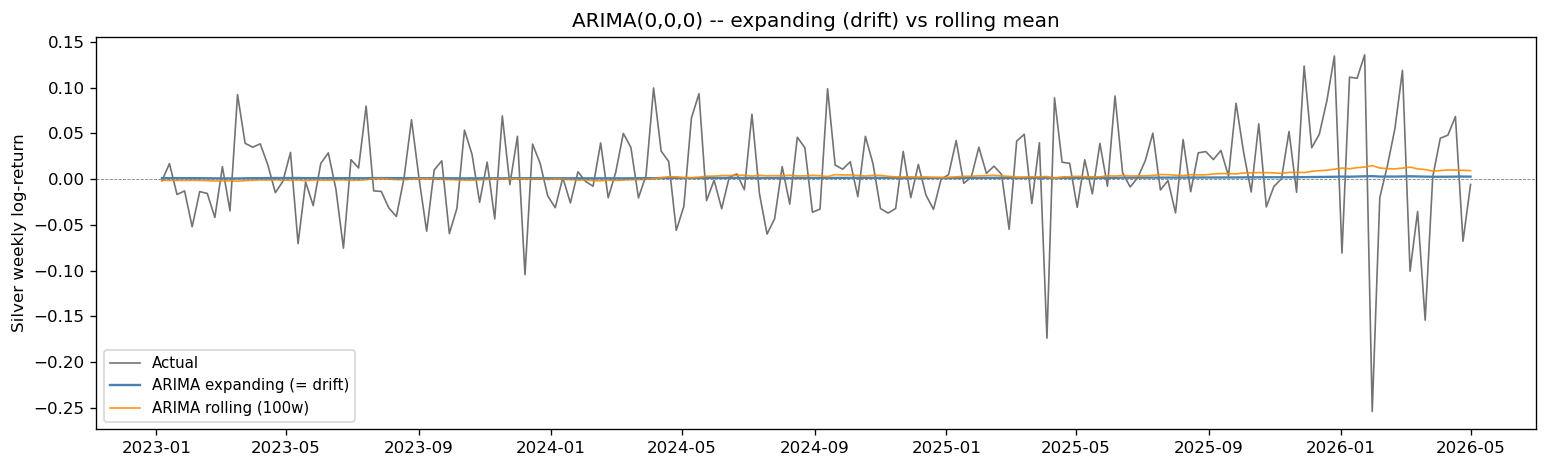

In [6]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(y_test.index, y_test.values,   label='Actual',                    lw=1,   color='black', alpha=0.55)
ax.plot(y_test.index, preds_arima_exp, label='ARIMA expanding (= drift)', lw=1.4, color='steelblue')
ax.plot(y_test.index, preds_arima_rol, label='ARIMA rolling (100w)',      lw=1,   color='darkorange', alpha=0.9)
ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.set_title('ARIMA(0,0,0) -- expanding (drift) vs rolling mean')
ax.set_ylabel('Silver weekly log-return')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Ablation ladder (ARIMAX, both windows)

**ARIMAX = ARIMA(0,0,0) + lagged exogenous regressors** — with order (0,0,0) it is OLS on the
lagged exog. Rung 0 is the returns-only baseline (the 6 cross-asset returns `gold, usd, copper,
sp500, vix, oil`); each higher rung adds one **public-information group**, read from
`feature_groups.json` so the ladder tracks the feature set automatically.

**Look-ahead discipline.** At week *t* we don't know this week's exog until it closes, so every
exogenous column is lagged 1 week (`.shift(1)`) before entering the model.

**Windows.** Each rung is run **both** expanding and rolling-100w (suffix `expanding` / `rolling (100w)`).

Rungs on top of the 6 returns: **GS** (gold/silver ratio), **FRED_daily** (Δreal-rate, Δbreakeven,
Δjobless-claims), **COT** (managed-money + commercial net positioning), **Reddit / News /
Sentiment**, **Macro+COT**, **GS+Sentiment**, **ALL** (kitchen sink). Each is a semi-strong-form
test: does that public channel beat the returns-only baseline?

**BestLag rungs** (filter screen, `02_features` §8b) — the filter counterpart to `technical_features_weekly`'s embedded
RF/LASSO selection. Each predictor enters at its train+val `|corr|`-maximising lag (pre-materialised,
so **no** extra `.shift(1)`); standalone exog (the ARIMA order supplies the AR base). `BestLag-All`
⊇ `BestLag-Sig90` (`p<0.10`) ⊇ `BestLag-Sig` (`p<0.05`). **Caveat:** the screen's strong
correlations are largely *test-period artefacts*, so read these as an optimistic upper bound, not a
clean OOS feature set.

In [7]:
import json

# Exog read is deferred to here (only the silver target was read in §1). Pull ONLY the columns the
# ablation ladder needs. Every one is already weekly-aggregated in the frame (returns /
# Delta-changes -> sum, levels / net-% positioning -> last, sentiment -> mean); we just .shift(1)
# it (the 1-week look-ahead lag).
with open('../../../data/processed/feature_groups.json') as f:
    GROUPS = json.load(f)

ret_cols      = ['gold_return', 'usd_return', 'copper_return',
                 'sp500_return', 'vix_return', 'oil_return']   # returns-only ARIMAX baseline
ABLATION_COLS = (GROUPS['YF_DAILY'] + GROUPS['FRED_DAILY'] + GROUPS['GS'] + GROUPS['COT']
                 + GROUPS['SENT'] + ['news_paid_sentiment_title'] + GROUPS['PMI'])
NEED_COLS     = list(dict.fromkeys(ABLATION_COLS + GROUPS['BESTLAG_ALL']))
exog = pd.read_csv('../../../data/processed/features_weekly.csv',
                   index_col='week_end', parse_dates=True, usecols=['week_end'] + NEED_COLS)

all_feat_lag  = exog[ABLATION_COLS].shift(1).fillna(0)   # 0=neutral: every col is a return/change/z-score/net-%/signed-sentiment (no raw levels, unlike BestLag below), so the shift warmup + sentiment gaps fill to no-signal (china_pmi_proxy is a ~0-centred balance-of-opinion level, so 0-fill is ~neutral too)

def make_exog(extra):
    cols = ret_cols + [c for c in extra if c in all_feat_lag.columns]
    return all_feat_lag.loc[y_train_full.index, cols], all_feat_lag.loc[y_test.index, cols]

WINDOWS = ('rolling (100w)', 'expanding')

def run_window(window, X_tr, X_te):
    if window == 'rolling (100w)':
        return rolling_forecast(y_train_full, y_test, best_order, window_size=100,
                                exog_train=X_tr, exog_test=X_te)
    return recursive_forecast(y_train_full, y_test, best_order, exog_train=X_tr, exog_test=X_te)

# Both windows for every rung. Rung 0 (label '') = ARIMAX returns-only, naming
# 'ARIMAX rolling (100w)' / 'ARIMAX expanding' to match the DM / saved-preds conventions.
# 'ARIMAX expanding' (returns-only, expanding) coincides with the drift+exog incremental base.
all_candidates = {}
LADDER = [
    ('',              []),
    ('+GS',           GROUPS['GS']),
    ('+FRED_daily',   GROUPS['FRED_DAILY']),
    ('+COT',          GROUPS['COT']),
    ('+Reddit',       ['reddit_sentiment']),
    ('+News',         ['news_sentiment']),
    ('+Sentiment',    GROUPS['SENT']),
    ('+Macro+COT',    GROUPS['FRED_DAILY'] + GROUPS['COT']),
    ('+GS+Sentiment', GROUPS['GS'] + GROUPS['SENT']),
    ('+ALL',          GROUPS['GS'] + GROUPS['FRED_DAILY'] + GROUPS['COT'] + GROUPS['SENT']),
    # Paid-news twins (title-only): mirror every GDELT-news rung, news_sentiment -> news_paid_sentiment_title
    ('+NewsPaid',         ['news_paid_sentiment_title']),
    ('+SentimentPaid',    ['reddit_sentiment', 'news_paid_sentiment_title']),
    ('+GS+SentimentPaid', GROUPS['GS'] + ['reddit_sentiment', 'news_paid_sentiment_title']),
    ('+ALLPaid',          GROUPS['GS'] + GROUPS['FRED_DAILY'] + GROUPS['COT'] + ['reddit_sentiment', 'news_paid_sentiment_title']),
    # PMI (china_pmi_proxy, point-in-time level) added to each FRED 'Macro' rung
    ('+FRED_daily+PMI',   GROUPS['FRED_DAILY'] + GROUPS['PMI']),
    ('+Macro+COT+PMI',    GROUPS['FRED_DAILY'] + GROUPS['COT'] + GROUPS['PMI']),
    ('+ALL+PMI',          GROUPS['GS'] + GROUPS['FRED_DAILY'] + GROUPS['COT'] + GROUPS['SENT'] + GROUPS['PMI']),
]
for label, extra in LADDER:
    X_tr, X_te = make_exog(extra)
    for window in WINDOWS:
        name = f'ARIMAX{label} {window}'
        print(f'Running {name}...')
        all_candidates[name] = run_window(window, X_tr, X_te)

# -- BestLag rungs (filter screen, 02_features §8b), both windows ------------------
# These columns are ALREADY pre-lagged at each feature's train+val |corr|-max lag, so they get
# NO extra .shift(1) (that would double-lag them). Standalone exog (the ARIMA order supplies the
# AR base), mirroring the tree BestLag rungs in 04/05. Members include monthly-macro levels, so
# ffill/bfill the warmup rather than fillna(0) (a 0 would be a wild outlier). Optimistic filter
# probe -- the screen's correlations are largely test-period artefacts (see the §8b caveat).
bestlag_lvl = exog[GROUPS['BESTLAG_ALL']].ffill().bfill()
BESTLAG_LADDER = [
    ('BestLag-All',   GROUPS['BESTLAG_ALL']),
    ('BestLag-Sig90', GROUPS['BESTLAG_SIG90']),
    ('BestLag-Sig',   GROUPS['BESTLAG_SIG']),
]
for label, cols in BESTLAG_LADDER:
    X_tr = bestlag_lvl.loc[y_train_full.index, cols]
    X_te = bestlag_lvl.loc[y_test.index,       cols]
    for window in WINDOWS:
        name = f'{label} {window}'
        print(f'Running {name}...')
        all_candidates[name] = run_window(window, X_tr, X_te)

print(f'\nBuilt {len(all_candidates)} ARIMAX variants ({len(WINDOWS)} windows).')

Running ARIMAX rolling (100w)...
Running ARIMAX expanding...
Running ARIMAX+GS rolling (100w)...
Running ARIMAX+GS expanding...
Running ARIMAX+FRED_daily rolling (100w)...
Running ARIMAX+FRED_daily expanding...
Running ARIMAX+COT rolling (100w)...
Running ARIMAX+COT expanding...
Running ARIMAX+Reddit rolling (100w)...
Running ARIMAX+Reddit expanding...
Running ARIMAX+News rolling (100w)...
Running ARIMAX+News expanding...
Running ARIMAX+Sentiment rolling (100w)...
Running ARIMAX+Sentiment expanding...
Running ARIMAX+Macro+COT rolling (100w)...
Running ARIMAX+Macro+COT expanding...
Running ARIMAX+GS+Sentiment rolling (100w)...
Running ARIMAX+GS+Sentiment expanding...
Running ARIMAX+ALL rolling (100w)...
Running ARIMAX+ALL expanding...
Running ARIMAX+NewsPaid rolling (100w)...
Running ARIMAX+NewsPaid expanding...
Running ARIMAX+SentimentPaid rolling (100w)...
Running ARIMAX+SentimentPaid expanding...
Running ARIMAX+GS+SentimentPaid rolling (100w)...
Running ARIMAX+GS+SentimentPaid expand

## 5. Evaluate

One table — RMSE / MAE / DA / WDA for the benchmarks, pure ARIMA (both windows), and every
ARIMAX rung (both windows). Two benchmark rows:

- **Naïve (`r_{t-1}`)** — persistence. Weak reference for a return target (high RMSE); kept for
  context, *not* the efficiency benchmark.
- **Drift (prevailing mean)** — expanding historical mean = random-walk-with-drift = **ARIMA(0,0,0)**
  by construction. The **correct EMH floor** for a return target (Welch-Goyal / Campbell-Thompson).
  Its sign stays positive, so directionally it is the **always-up** line and its WDA = the
  magnitude-weighted up-share (≈0.59 full-sample, ≈0.49 ex-2025 — the rest is the 2025 bull).

**Primary metric = RMSE / DM-vs-Drift (magnitude); WDA is the secondary directional lens.**

**Metric definitions** — click to expand. RMSE / MAE score the conditional **mean** (the magnitude axis the EMH claim lives on) and OOS R² is the effect size on that same axis vs the Drift floor; DA / WDA are the **directional** read. Significance for all of these sits in §8. Full standalone reference: [`notes.md`](notes.md).

<details>
<summary>&nbsp;<b>RMSE / MAE</b> &nbsp; <code>Descriptive</code> <code>Magnitude</code> &nbsp;— point-forecast error, the primary descriptive metric</summary>

| | |
|---|---|
| **RMSE** | $\sqrt{\tfrac{1}{n}\sum_i (y_i-\hat y_i)^2}$ |
| **MAE** | $\tfrac{1}{n}\sum_i \lvert y_i-\hat y_i\rvert$ |
| **Why primary** | The efficiency claim is about the conditional mean; RMSE / MAE measure how far forecasts sit from it. |
| **Caveat** | Weekly returns carry ~5%/wk innovation variance that dominates RMSE — every model (incl. Drift) collapses onto roughly the unconditional std, so RMSE *alone* barely separates models. This is exactly why OOS R² + DM sit on top of it (§8). |
| **Load-bearing?** | No — rank and describe only. |

</details>

<details>
<summary>&nbsp;<b>OOS R²</b> — Campbell–Thompson (2008) &nbsp; <code>Effect size</code> <code>Magnitude</code> &nbsp;— how much does the model beat the random walk?</summary>

| | |
|---|---|
| **Formula** | $R^2_{OS}=1-\dfrac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y_i)^2}$ &nbsp; (benchmark $\bar y_i$ = the prevailing-mean / Drift forecast) |
| **What it answers** | The **effect size** on the magnitude axis — % reduction in OOS squared error vs the random walk; the standard return-predictability number. Shown as the `r2_os` column in the table below. |
| **How to read** | $>0$ ⇒ beats Drift OOS; $\le 0$ (the usual return result) ⇒ worse than just predicting the prevailing mean. Drift's own value is 0 by construction. |
| **Pairs with** | DM (§8) — effect size still needs a significance test; a small positive R² can be noise. |
| **Load-bearing?** | The effect-size half of the floor test — its significance is the DM-vs-Drift test in §8. |

</details>

<details>
<summary>&nbsp;<b>DA</b> — directional accuracy &nbsp; <code>Descriptive</code> <code>Direction</code> &nbsp;— naïve sign hit-rate</summary>

| | |
|---|---|
| **Formula** | $\tfrac{1}{n}\sum_i \mathbf{1}\!\left[\operatorname{sign}(y_i)=\operatorname{sign}(\hat y_i)\right]$ |
| **Caveat** | Blind to the base rate — in an up-market "always up" scores high while saying nothing. Does not adjust for the unconditional up-frequency. |
| **Load-bearing?** | No. WDA is the better directional descriptive; PT (§8b) is its significance test. |

</details>

<details>
<summary>&nbsp;<b>WDA</b> — weighted DA &nbsp; <code>Descriptive</code> <code>Direction</code> &nbsp;— the secondary directional lens</summary>

| | |
|---|---|
| **Formula** | $\dfrac{\sum_i \lvert y_i\rvert \cdot \mathbf{1}\!\left[\operatorname{sign}(y_i)=\operatorname{sign}(\hat y_i)\right]}{\sum_i \lvert y_i\rvert}$ |
| **Why better than DA** | Credits getting the sign right on the weeks that *moved* and ignores chop — a coin-flip on a 0.01% week is irrelevant; a correct call on a 5% week matters. |
| **`best_name` usage** | The notebook flags the WDA-argmax variant as "best", but that is **descriptive display only** — the verdict rests on DM-vs-Drift (§8), not the noisy, bull-inflated WDA ranking. |
| **Load-bearing?** | No — secondary descriptive. PT is its significance partner. |

</details>

In [8]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../src'))
from eval_utils import evaluate, period_metrics, diebold_mariano, oos_r2, PERIODS

actuals    = y_test.values
test_index = y_test.index

# Naïve (persistence): this week = last week's return.
naive_pred = np.concatenate([[np.nan], actuals[:-1]])

# Drift / random-walk-with-drift: prevailing (expanding) mean of past returns (Welch-Goyal).
# No look-ahead -- at week t it averages all returns observed before t. The mean stays positive,
# so directionally it is an 'always-up' call. This IS ARIMA(0,0,0) by construction, so
# 'beat the drift' = the weak-form test.
_hist = list(y_train_full.values)
drift_pred = np.empty(len(actuals))
for _t in range(len(actuals)):
    drift_pred[_t] = np.mean(_hist)
    _hist.append(float(actuals[_t]))

# Single table: benchmarks + pure ARIMA (both windows) + every ARIMAX rung.
eval_preds = {
    'Naive (t-1 week)':        naive_pred,
    'Drift (prevailing mean)': drift_pred,
    'ARIMA expanding':         preds_arima_exp,
    'ARIMA rolling (100w)':    preds_arima_rol,
    **all_candidates,
}
metrics = [evaluate(name, actuals, pred) for name, pred in eval_preds.items()]

metrics_df = pd.DataFrame([m for m in metrics if m is not None])
# OOS R^2 vs the Drift floor (Campbell-Thompson 2008) -- effect size; >0 beats the random walk OOS.
# Drift is the benchmark so its own R2_OS is 0 by construction. Shown alongside RMSE/MAE/DA/WDA;
# its significance is the DM-vs-Drift test in section 8.
metrics_df['r2_os'] = [oos_r2(actuals, eval_preds[m], drift_pred) * 100 for m in metrics_df['model']]
metrics_df = metrics_df[['model', 'rmse', 'mae', 'r2_os', 'dir_acc', 'wda']]   # r2_os shown next to the error metrics
metrics_df.to_csv('../../../data/processed/metrics_arima.csv', index=False)

# Drift WDA by period: Drift's sign is always positive, so this is the Drift / ARIMA(0,0,0)
# directional line -- the WDA to beat.
print('\nDrift WDA by period (directional benchmark to beat):')
for _lbl, (_a, _b) in PERIODS.items():
    _s = y_test.loc[_a:_b]
    if len(_s):
        _au = np.sum(np.abs(_s.values) * (_s.values > 0)) / np.sum(np.abs(_s.values))
        print(f'  {_lbl:20s} WDA={_au:.3f}  (n={len(_s)})')

metrics_df

Naive (t-1 week)                               RMSE=0.07594  MAE=0.05397  DA=0.491  WDA=0.490
Drift (prevailing mean)                        RMSE=0.05190  MAE=0.03714  DA=0.557  WDA=0.588
ARIMA expanding                                RMSE=0.05190  MAE=0.03714  DA=0.557  WDA=0.588
ARIMA rolling (100w)                           RMSE=0.05174  MAE=0.03690  DA=0.557  WDA=0.573
ARIMAX rolling (100w)                          RMSE=0.05323  MAE=0.03765  DA=0.523  WDA=0.483
ARIMAX expanding                               RMSE=0.05220  MAE=0.03683  DA=0.569  WDA=0.555
ARIMAX+GS rolling (100w)                       RMSE=0.05450  MAE=0.03767  DA=0.580  WDA=0.573
ARIMAX+GS expanding                            RMSE=0.05200  MAE=0.03670  DA=0.598  WDA=0.606
ARIMAX+FRED_daily rolling (100w)               RMSE=0.05371  MAE=0.03787  DA=0.557  WDA=0.512
ARIMAX+FRED_daily expanding                    RMSE=0.05236  MAE=0.03695  DA=0.580  WDA=0.521
ARIMAX+COT rolling (100w)                      RMSE=0.05468 

,model,rmse,mae,r2_os,dir_acc,wda
0,Naive (t-1 week),0.075941,0.053966,-112.857285,0.491329,0.489862
1,Drift (prevailing mean),0.051902,0.037135,0.000000,0.557471,0.587779
2,ARIMA expanding,0.051903,0.037135,-0.001813,0.557471,0.587779
3,ARIMA rolling (100w),0.051745,0.036896,0.606302,0.557471,0.572523
4,ARIMAX rolling (100w),0.053226,0.037650,-5.166460,0.522989,0.482664
5,ARIMAX expanding,0.052196,0.036835,-1.135784,0.568966,0.554856
6,ARIMAX+GS rolling (100w),0.054500,0.037675,-10.262602,0.580460,0.573317
7,ARIMAX+GS expanding,0.052001,0.036703,-0.380822,0.597701,0.605666
8,ARIMAX+FRED_daily rolling (100w),0.053707,0.037866,-7.074915,0.557471,0.511996
9,ARIMAX+FRED_daily expanding,0.052360,0.036949,-1.771855,0.580460,0.521206


## 6. Sub-period robustness + best-variant selection

Pick the best ARIMAX two ways — by **RMSE** (primary, magnitude — §3a) and by **WDA** (secondary,
directional) — and break each down by calendar year to check the result isn't driven by one regime.

**Saved for cross-model use:** WDA-best keeps the legacy filenames (`period_arimax_weekly.csv`,
`preds_arimax_best_weekly.csv`) so `evaluation.ipynb` is untouched; RMSE-best is saved alongside
(`period_arimax_rmse_weekly.csv`, `preds_arimax_bestrmse_weekly.csv`).

With order (0,0,0) expect the two picks to differ: RMSE-best tends to be the *timid* variant
(closest to the drift — extra features add variance that hurts RMSE), WDA-best a directional bettor.

In [9]:
def _best_by_wda(candidates, actuals):
    return max(candidates, key=lambda k:
        np.nansum(np.abs(actuals) * (np.sign(actuals) == np.sign(candidates[k]))) /
        np.nansum(np.abs(actuals)))

def _best_by_rmse(candidates, actuals):
    return min(candidates, key=lambda k:
        np.sqrt(np.nanmean((actuals - candidates[k]) ** 2)))

def _period_r2(pred):
    # OOS R^2 vs the Drift floor, per calendar sub-period (Campbell-Thompson) -- the effect-size
    # companion to the per-period error metrics. oos_r2 masks NaN internally.
    drift_s, pred_s = pd.Series(drift_pred, index=test_index), pd.Series(pred, index=test_index)
    r2 = {}
    for _lbl, (_a, _b) in PERIODS.items():
        _y, _p, _d = y_test.loc[_a:_b].values, pred_s.loc[_a:_b].values, drift_s.loc[_a:_b].values
        if len(_y):
            r2[_lbl] = oos_r2(_y, _p, _d) * 100
    return r2

def _show_period(pred, csv):
    res = period_metrics(actuals, pred, test_index, PERIODS)   # RMSE / MAE / DA / WDA per period
    r2  = _period_r2(pred)
    res['R2_OS'] = [r2.get(lbl, np.nan) for lbl in res.index]   # effect size vs Drift (display only)
    display(res[['n', 'RMSE', 'MAE', 'R2_OS', 'DA', 'WDA']].style
            .format({'n': '{:.0f}', 'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2_OS': '{:+.2f}',
                     'DA': '{:.3f}', 'WDA': '{:.3f}'})
            .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.4, vmax=0.7))
    res[['n', 'DA', 'WDA']].to_csv(csv)   # legacy schema saved -- evaluation.ipynb reads these

def _save_preds(pred, csv):
    pd.DataFrame({'actual': actuals, 'predicted': pred}, index=test_index) \
      .rename_axis('Date').to_csv(csv)

# -- Pure ARIMA (no exog) -----------------------------------------------------
arima_only      = {'ARIMA expanding': preds_arima_exp, 'ARIMA rolling (100w)': preds_arima_rol}
best_arima_name = _best_by_wda(arima_only, actuals)     # WDA-best (legacy: feeds period_arima)
best_arima_rmse = _best_by_rmse(arima_only, actuals)
print(f'Best ARIMA  -- WDA: {best_arima_name}  |  RMSE: {best_arima_rmse}')
_show_period(arima_only[best_arima_name], '../../../data/processed/period_arima_weekly.csv')

# -- Best ARIMAX -- by WDA (directional) and RMSE (magnitude, primary) --------
best_arimax_name = _best_by_wda(all_candidates, actuals)
best_arimax_rmse = _best_by_rmse(all_candidates, actuals)
best_pred        = all_candidates[best_arimax_name]
best_pred_rmse   = all_candidates[best_arimax_rmse]
print(f'\nBest ARIMAX -- WDA: {best_arimax_name}  |  RMSE: {best_arimax_rmse}')
print('\nWDA-best by period:')
_show_period(best_pred,      '../../../data/processed/period_arimax_weekly.csv')
print('RMSE-best by period:')
_show_period(best_pred_rmse, '../../../data/processed/period_arimax_rmse_weekly.csv')

# -- Save winning predictions for cross-model DM in evaluation.ipynb ----------
# Legacy names = WDA-best (evaluation.ipynb untouched); RMSE-best saved alongside.
_save_preds(arima_only[best_arima_name], '../../../data/processed/preds_arima_best_weekly.csv')
_save_preds(arima_only[best_arima_rmse], '../../../data/processed/preds_arima_bestrmse_weekly.csv')
_save_preds(best_pred,                   '../../../data/processed/preds_arimax_best_weekly.csv')
_save_preds(best_pred_rmse,              '../../../data/processed/preds_arimax_bestrmse_weekly.csv')
print('\nSaved: arima/arimax period + preds (WDA-best legacy names, RMSE-best alongside).')

Best ARIMA  -- WDA: ARIMA expanding  |  RMSE: ARIMA rolling (100w)


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0400,0.0318,+0.00,0.481,0.492
2024 (bull start),52,0.0380,0.0299,-0.00,0.500,0.570
2025 (bull run),52,0.0499,0.0352,-0.01,0.692,0.757
2026 (YTD),18,0.1003,0.0791,+0.00,0.556,0.498
── Full test ──,174,0.0519,0.0371,-0.00,0.557,0.588



Best ARIMAX -- WDA: ARIMAX+ALLPaid rolling (100w)  |  RMSE: ARIMAX+GS+Sentiment expanding

WDA-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0385,0.0308,+7.45,0.673,0.761
2024 (bull start),52,0.0458,0.0359,-45.55,0.538,0.493
2025 (bull run),52,0.0490,0.0366,+3.46,0.654,0.725
2026 (YTD),18,0.1151,0.0880,-31.47,0.611,0.492
── Full test ──,174,0.0562,0.0400,-17.18,0.621,0.628


RMSE-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0389,0.0301,+5.41,0.692,0.664
2024 (bull start),52,0.0366,0.0284,+7.35,0.615,0.691
2025 (bull run),52,0.0507,0.0358,-3.34,0.596,0.583
2026 (YTD),18,0.1016,0.0804,-2.54,0.389,0.395
── Full test ──,174,0.0518,0.0365,+0.23,0.609,0.588



Saved: arima/arimax period + preds (WDA-best legacy names, RMSE-best alongside).


## 7. Predicted vs actual — best ARIMA vs best ARIMAX

Full test window, best variant per family, **two panels**:

- **Top — WDA-best** (directional pick): the variant that calls the most sign, magnitude-weighted.
- **Bottom — RMSE-best** (magnitude pick): the variant with the lowest squared error — which, at
  order (0,0,0), is the *timid* one that stays closest to the drift.

ARIMA(0,0,0) is a near-flat line at the conditional mean (≈ the weekly drift); the rolling ARIMAX
moves week-to-week as the lagged exog regressors shift.

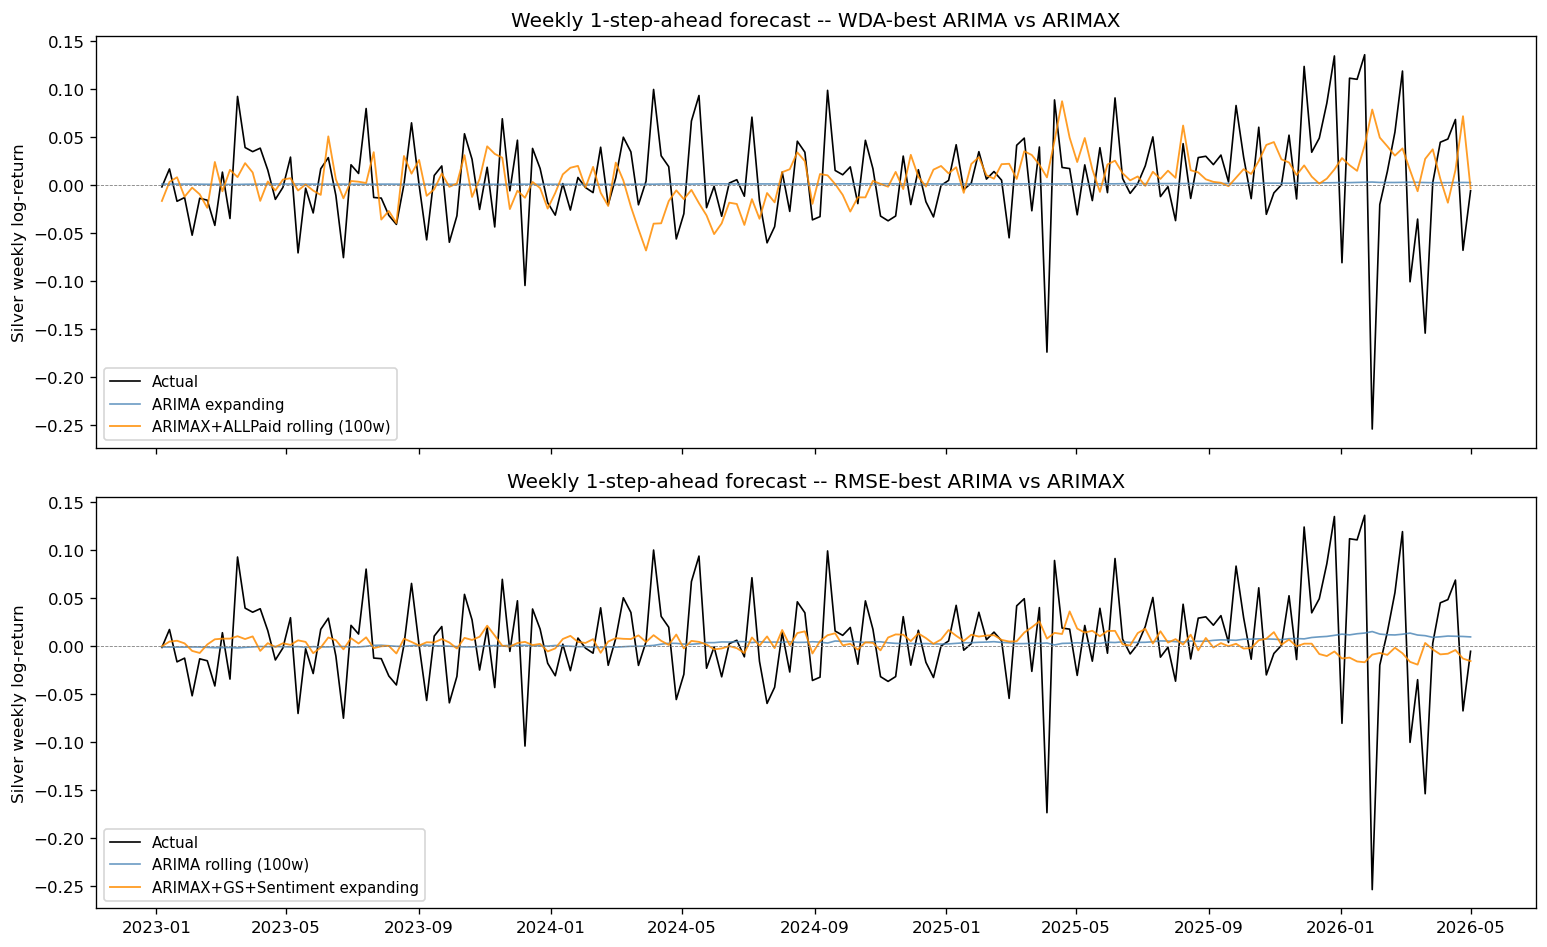

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
panels = [('WDA-best',  best_arima_name, best_arimax_name, best_pred),
          ('RMSE-best', best_arima_rmse, best_arimax_rmse, best_pred_rmse)]
for ax, (tag, aname, xname, xpred) in zip(axes, panels):
    ax.plot(test_index, actuals,           label='Actual', lw=1,   color='black')
    ax.plot(test_index, arima_only[aname], label=aname,    lw=1,   alpha=0.8,  color='steelblue')
    ax.plot(test_index, xpred,             label=xname,    lw=1.1, alpha=0.85, color='darkorange')
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.set_title(f'Weekly 1-step-ahead forecast -- {tag} ARIMA vs ARIMAX')
    ax.set_ylabel('Silver weekly log-return')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Significance tests

The descriptive metrics in §5 rank the models; this section asks whether the differences are
**statistically real**. Three tests, all against the **Drift** floor (= ARIMA(0,0,0), the random
walk — so the cross-asset EXOG is on trial too). The DM-vs-Drift floor is the load-bearing
efficiency verdict; PT is the secondary directional lens. Full reference: [`notes.md`](notes.md).

| Test | Asks | Axis | Role |
|---|---|---|---|
| **DM — squared error** (§8) | Does *any* model beat the random walk? | magnitude | **load-bearing** |
| **DM — absolute error** (§8) | …and does that survive heavy tails? | magnitude | robustness |
| **Pesaran–Timmermann** (§8b) | Do the *sign* calls beat chance? | direction | secondary |

Each test is explained in detail, then run. **Effect size** lives with §5: OOS R² is the % MSE
reduction vs Drift and is already in the §5 metrics table — the DM tests below supply its significance.
§8c then re-runs the whole battery with the 2025 bull removed.

**One shared mechanic across both DM tests — Newey–West lag-1.** The DM statistic is
$\bar d / \sqrt{\widehat{\text{Var}}(\bar d)}$, where $d_t = \text{loss}_{\text{Drift},t} - \text{loss}_{\text{model},t}$.
The denominator is the tricky part: the naïve estimate is $\gamma_0/n$ (variance of $d$ divided by $n$),
which assumes every weekly loss difference is independent. That is usually wrong — a volatile silver
period makes both models look bad for several consecutive weeks, so nearby $d_t$ are correlated.
Ignoring that understates $\widehat{\text{Var}}(\bar d)$ and overstates significance. Newey–West
replaces $\gamma_0$ with $(\gamma_0 + 2\gamma_1)$: the factor-2 $\gamma_1$ term accounts for the
lag-1 autocovariance appearing from both sides of $t$ in the long-run variance sum. For a 1-week-ahead
forecast, lag 1 is the natural dependence horizon — a defensible, simple correction that is much
better than assuming independence.


### Diebold–Mariano vs Drift — squared-error floor (the load-bearing test)

The headline efficiency test: does any model produce significantly lower **squared** forecast errors
than the Drift under the loss function that $R^2_{OS}$ is also based on? Expand for the detail.

<details>
<summary>&nbsp;<b>Diebold–Mariano</b> (squared error) &nbsp; <code>Significance</code> <code>Magnitude</code> &nbsp;— the proper significance test for R²_OS</summary>

| | |
|---|---|
| **H₀** | Equal predictive accuracy — $E[d_t] = 0$ where $d_t = \text{loss}_{\text{Drift},t} - \text{loss}_{\text{model},t}$. |
| **What it answers** | Is the gap in MSFE between a model and Drift statistically significant? This is the natural companion to $R^2_{OS}$: both are MSFE-based, so DM is exactly the significance test for the effect size in §5. |
| **Statistic** | $\text{DM}=\dfrac{\bar d}{\sqrt{(\gamma_0+2\gamma_1)/n}}\sim N(0,1)$ &nbsp; (see Newey–West note in §8 intro) |
| **Sign convention** | `pred1` = Drift always. $\bar d > 0$ means Drift had larger loss → **positive** DM = model beats Drift. **Negative** DM = Drift wins. |
| **Why squared error here** | Squared loss is minimised by the conditional mean — the object the efficiency claim is about. A 4× larger error produces 16× the squared loss, so SE DM is sensitive to the same big return shocks that dominate $R^2_{OS}$. Both tests live or die on the same weeks — making DM-SE the internally consistent significance test. |
| **Floor vs incremental** | Only the **floor** test (model vs Drift) runs in the aligned trio. The incremental DM (variant vs ARIMAX base) was dropped — covariates are public info, so the floor already puts the base on trial, and incremental can mislead (a variant beats EXOG while EXOG loses to Drift). |
| **Finding** | Never DM-significant for any public-info model; feature-rich / rolling variants are significantly *worse*. |
| **Load-bearing?** | **Yes — the primary verdict.** |

</details>


In [11]:
# Weak + semi-strong floor vs the Drift (prevailing-mean / random walk = ARIMA(0,0,0), the own-history
# floor -- so the cross-asset EXOG is on trial too). THIS is the load-bearing efficiency test.
# Effect size (OOS R^2) is reported in the section-5 metrics table; here DM gives its significance.
weak_set = {
    'ARIMA expanding':      preds_arima_exp,
    'ARIMA rolling (100w)': preds_arima_rol,
    **all_candidates,
}
print('Diebold-Mariano -- vs Drift floor   [squared error]')
print('Weak + semi-strong test: can any model beat the no-predictability drift?')
print('-' * 95)
for name, pred in weak_set.items():
    diebold_mariano(actuals, drift_pred, pred, 'Drift', name)

Diebold-Mariano -- vs Drift floor   [squared error]
Weak + semi-strong test: can any model beat the no-predictability drift?
-----------------------------------------------------------------------------------------------
Drift                                    vs ARIMA expanding                           DM=-1.348  p=0.178  (ns)  -> winner: tie
Drift                                    vs ARIMA rolling (100w)                      DM=+0.336  p=0.737  (ns)  -> winner: tie
Drift                                    vs ARIMAX rolling (100w)                     DM=-2.039  p=0.041  *     -> winner: Drift
Drift                                    vs ARIMAX expanding                          DM=-1.026  p=0.305  (ns)  -> winner: tie
Drift                                    vs ARIMAX+GS rolling (100w)                  DM=-1.895  p=0.058  (ns)  -> winner: tie
Drift                                    vs ARIMAX+GS expanding                       DM=-0.135  p=0.893  (ns)  -> winner: tie
Drift          

### Diebold–Mariano vs Drift — absolute-error loss (robustness)

The same DM framework, but with loss $\lvert y-\hat y\rvert$ instead of $(y-\hat y)^2$. Expand for
why this asks a slightly different question and why we want both.

<details>
<summary>&nbsp;<b>Diebold–Mariano</b> (absolute error) &nbsp; <code>Significance</code> <code>Magnitude</code> &nbsp;— robustness check against heavy-tailed returns</summary>

| | |
|---|---|
| **Same machinery** | Identical statistic / sign convention / Newey–West as the SE version — only the loss changes. |
| **What it actually asks** | Does the model generally get closer to the realised return, *without letting a few huge weeks dominate*? It is not testing exactly the same thing as $R^2_{OS}$ (which is MSFE-based); it is asking whether the improvement survives a less outlier-sensitive criterion. |
| **Why this matters for returns** | A 4× larger error gives 16× the squared loss but only 4× the absolute loss. Silver returns have occasional extreme weeks (Reddit squeeze, COVID, 2025 bull leg). SE DM is dominated by those weeks — a model can look good or bad on SE DM almost entirely because of one or two outlier weeks. AE down-weights them. |
| **Why SE stays the headline** | $R^2_{OS}$ is MSFE-based and SE DM is its proper significance test. AE is a robustness check: a model that beats Drift under SE but not AE (or vice versa) is a weaker result than one that clears both. A real, broad improvement should survive the loss-function change. |
| **Finding** | Consistent with SE: no model beats the floor under AE either. |

</details>


In [12]:
# Robustness -- floor test under ABSOLUTE-error loss (heavy-tailed returns -> squared-error DM is
# low-powered; |error| more robust). Squared error (above) stays the headline.
print('Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]')
print('-' * 95)
for name, pred in weak_set.items():
    diebold_mariano(actuals, drift_pred, pred, 'Drift', name, loss='ae')

Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]
-----------------------------------------------------------------------------------------------
Drift                                    vs ARIMA expanding                           DM=-0.915  p=0.360  (ns)  -> winner: tie
Drift                                    vs ARIMA rolling (100w)                      DM=+0.753  p=0.452  (ns)  -> winner: tie
Drift                                    vs ARIMAX rolling (100w)                     DM=-0.766  p=0.444  (ns)  -> winner: tie
Drift                                    vs ARIMAX expanding                          DM=+1.019  p=0.308  (ns)  -> winner: tie
Drift                                    vs ARIMAX+GS rolling (100w)                  DM=-0.624  p=0.533  (ns)  -> winner: tie
Drift                                    vs ARIMAX+GS expanding                       DM=+0.826  p=0.409  (ns)  -> winner: tie
Drift                                    vs ARIMAX+FRED_daily rolling (1

## 8b. Pesaran–Timmermann — directional test (secondary lens)

The DM tests above are **magnitude** tests; WDA / DA are **directional** descriptives, so their
significance needs a directional test. Expand for the detail.

<details>
<summary>&nbsp;<b>Pesaran–Timmermann</b> (PT) &nbsp; <code>Significance</code> <code>Direction</code> &nbsp;— do the sign calls beat chance?</summary>

| | |
|---|---|
| **H₀** | Predicted and actual signs are independent — no market-timing skill — *accounting for the unconditional up-rate*. |
| **Key subtlety** | Nets out the base rate: "always up in an up-market" does **not** pass. This is what separates PT from raw DA. |
| **Output** | `skill` (significant, PT > 0 — genuine timing) · `perverse` (significant, PT < 0 — systematically wrong signs, still information) · `tie` (chance). |
| **Drift degenerate** | A constant-sign forecast → PT returns `n/a`; a built-in sanity check, not a bug. |
| **Heavy caveats** | (a) the best-by-WDA variant is the max over ~12 ablations, so its p-value is selection-biased / optimistic; (b) the one apparent signal (ARIMA COT-positioning) does **not** replicate in RF (1/38 ≈ chance), XGB (0/38) or LSTM (0/15). |
| **Finding** | Treat as a non-replicating footnote — an adaptive-markets aside (Lo 2004); it does not touch the magnitude-efficiency verdict. |
| **Load-bearing?** | No — secondary directional lens only. |

</details>

In [13]:
from eval_utils import pesaran_timmermann

# Directional (secondary) lens — Pesaran-Timmermann market-timing test on the SIGN calls,
# run across ALL variants to size the selection / multiple-testing picture. DM-vs-drift
# stays the primary (magnitude) efficiency test; PT only asks whether the sign beats chance.
print('Pesaran-Timmermann directional test — full test window')
print('H0: predicted & actual signs independent (no timing skill)  |  * p<0.05  ** p<0.01  *** p<0.001')
print('-' * 95)
pesaran_timmermann(actuals, drift_pred,      name='Drift (always-up)')   # degenerate ref
pesaran_timmermann(actuals, preds_arima_exp, name='ARIMA expanding')     # degenerate ref
pt_results = {n: pesaran_timmermann(actuals, p, name=n) for n, p in all_candidates.items()}

# Multiple-testing picture (rough — the variants are correlated, so chance is a heuristic).
_tested = [r for r in pt_results.values() if not np.isnan(r['p'])]
_sig    = {n: r for n, r in pt_results.items() if not np.isnan(r['p']) and r['p'] < 0.05}
print(f'\n{len(_sig)}/{len(_tested)} variants significant at p<0.05 '
      f'(~{0.05 * len(_tested):.1f} expected by chance under H0): {list(_sig)}')

# Per-period PT for the best-by-WDA variant — is the full-window result driven by one regime?
print(f'\nPer-period PT — {best_arimax_name}:')
_bp = pd.Series(best_pred, index=test_index)
for _lbl, (_a, _b) in PERIODS.items():
    _yy = y_test.loc[_a:_b].values
    _pp = _bp.loc[_a:_b].values
    if len(_yy) >= 12:
        pesaran_timmermann(_yy, _pp, name=f'  {_lbl}  (n={len(_yy)})')

Pesaran-Timmermann directional test — full test window
H0: predicted & actual signs independent (no timing skill)  |  * p<0.05  ** p<0.01  *** p<0.001
-----------------------------------------------------------------------------------------------
Drift (always-up)                         DA=0.557  DA|indep=0.557  PT degenerate (constant-sign forecast)  -> winner: n/a
ARIMA expanding                           DA=0.557  DA|indep=0.557  PT degenerate (constant-sign forecast)  -> winner: n/a
ARIMAX rolling (100w)                     DA=0.523  DA|indep=0.510  PT=+0.354  p=0.724  (ns)  -> winner: tie (chance)
ARIMAX expanding                          DA=0.569  DA|indep=0.514  PT=+1.512  p=0.131  (ns)  -> winner: tie (chance)
ARIMAX+GS rolling (100w)                  DA=0.580  DA|indep=0.515  PT=+1.802  p=0.071  (ns)  -> winner: tie (chance)
ARIMAX+GS expanding                       DA=0.598  DA|indep=0.526  PT=+2.138  p=0.033  *     -> winner: ARIMAX+GS expanding
ARIMAX+FRED_daily rolling (1

## 8c. Robustness — drop the 2025 bull run (full battery)

2025 carries the entire always-up line (its WDA ≈0.59 full-sample vs ≈0.49 without it), so once the
full-window tests are done, re-run **the whole battery** — metrics + OOS R² + DM floor (se/ae) + PT —
on **2023 + 2024 + 2026** only. Evaluation-only (models unchanged, still trained walk-forward through
2025); pooled (per-year DM is underpowered). The efficiency conclusion *strengthens* once the bull is gone.

In [14]:
from eval_utils import pesaran_timmermann
# Full battery on the non-bull window. Evaluation-only (forecasts unchanged); pooled for DM power.
mask_ex25 = np.asarray(test_index.year != 2025)
a_ex      = actuals[mask_ex25]
drift_ex  = drift_pred[mask_ex25]
au_ex     = np.sum(np.abs(a_ex) * (a_ex > 0)) / np.sum(np.abs(a_ex))
print(f'Ex-2025 sample: {int(mask_ex25.sum())} weeks  |  always-up WDA = {au_ex:.3f}')

print('\nMetrics (2025 excluded) -- RMSE / MAE / DA / WDA:')
evaluate('Drift (prevailing mean)', a_ex, drift_ex)
for name, pred in weak_set.items():
    evaluate(name, a_ex, np.asarray(pred)[mask_ex25])

print('\nOOS R^2 vs Drift (2025 excluded) -- >0 beats the random walk:')
print('-' * 95)
for name, pred in weak_set.items():
    _r2 = oos_r2(a_ex, np.asarray(pred)[mask_ex25], drift_ex) * 100
    print(f'  {name:40s} R2_OS = {_r2:+6.2f}%   -> winner: {name if _r2 > 0 else "Drift"}')

print('\nDM -- vs Drift floor, 2025 excluded [squared error]:')
print('-' * 95)
for name, pred in weak_set.items():
    diebold_mariano(a_ex, drift_ex, np.asarray(pred)[mask_ex25], 'Drift', name)

print('\nDM -- vs Drift floor, 2025 excluded [absolute-error loss, robustness]:')
print('-' * 95)
for name, pred in weak_set.items():
    diebold_mariano(a_ex, drift_ex, np.asarray(pred)[mask_ex25], 'Drift', name, loss='ae')

print('\nPesaran-Timmermann (2025 excluded) -- directional sign test:')
print('-' * 95)
for name, pred in all_candidates.items():
    pesaran_timmermann(a_ex, np.asarray(pred)[mask_ex25], name=name)

Ex-2025 sample: 122 weeks  |  always-up WDA = 0.520

Metrics (2025 excluded) -- RMSE / MAE / DA / WDA:
Drift (prevailing mean)                        RMSE=0.05275  MAE=0.03796  DA=0.500  WDA=0.520
ARIMA expanding                                RMSE=0.05275  MAE=0.03796  DA=0.500  WDA=0.520
ARIMA rolling (100w)                           RMSE=0.05310  MAE=0.03799  DA=0.500  WDA=0.498
ARIMAX rolling (100w)                          RMSE=0.05531  MAE=0.03954  DA=0.467  WDA=0.394
ARIMAX expanding                               RMSE=0.05307  MAE=0.03758  DA=0.590  WDA=0.547
ARIMAX+GS rolling (100w)                       RMSE=0.05616  MAE=0.03890  DA=0.541  WDA=0.512
ARIMAX+GS expanding                            RMSE=0.05276  MAE=0.03740  DA=0.582  WDA=0.600
ARIMAX+FRED_daily rolling (100w)               RMSE=0.05585  MAE=0.03943  DA=0.516  WDA=0.432
ARIMAX+FRED_daily expanding                    RMSE=0.05322  MAE=0.03759  DA=0.582  WDA=0.495
ARIMAX+COT rolling (100w)                      RMSE

## 9. 2026 zoom — actual vs best model

Focuses on the most recent out-of-sample slice. Shows the **drift floor** plus both winners (WDA-best and RMSE-best); the RMSE-best line hugs the drift — minimising squared error just reproduces the random walk — while the WDA-best is the directional bettor.

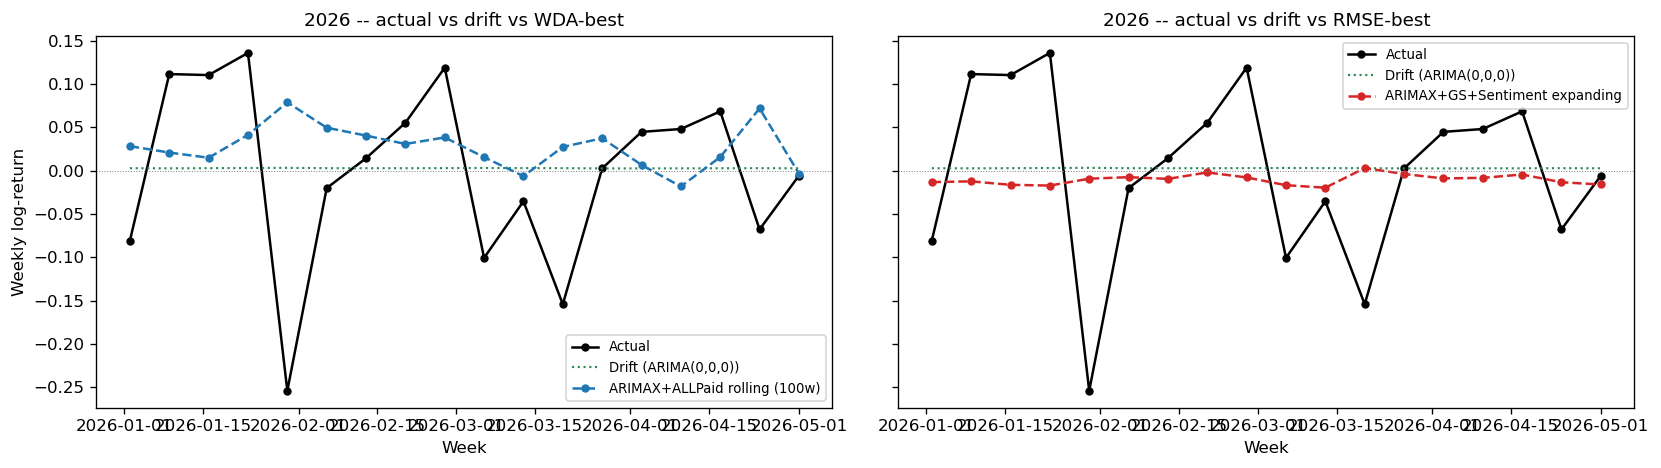

In [15]:
df26 = pd.DataFrame({'actual': actuals, 'drift': drift_pred,
                     'wda_best': best_pred, 'rmse_best': best_pred_rmse},
                    index=test_index).loc['2026':]

if df26.empty:
    print('No 2026 data in test set yet.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
    panels = [('wda_best', best_arimax_name, '#1f77b4', 'WDA-best'),
              ('rmse_best', best_arimax_rmse, '#d62728', 'RMSE-best')]
    for ax, (col, vname, color, tag) in zip(axes, panels):
        ax.plot(df26.index, df26['actual'], color='black',    lw=1.5, marker='o', ms=4, label='Actual')
        ax.plot(df26.index, df26['drift'],  color='seagreen', lw=1.3, ls=':',  label='Drift (ARIMA(0,0,0))')
        ax.plot(df26.index, df26[col],      color=color,      lw=1.5, marker='o', ms=4, ls='--', label=vname)
        ax.axhline(0, color='grey', lw=0.6, ls=':')
        ax.set_title(f'2026 -- actual vs drift vs {tag}', fontsize=11)
        ax.set_xlabel('Week')
        ax.legend(fontsize=8)
    axes[0].set_ylabel('Weekly log-return')
    plt.tight_layout()
    plt.show()

## 9b. ARIMAX coefficient inspection (interpretability)

This is the ARIMAX analogue of RF/XGB feature importance and VAR Granger diagnostics: an in-sample
look at which lagged public-information regressors carry linear signal in the fitted model.

Because the selected order is ARIMA$(0,0,0)$, each ARIMAX refit is effectively a linear regression of
next-week `silver_return` on the lagged exogenous variables in that rung. The tables below refit only
on **train+val** — the same pre-test information set used for selection — so the test period remains
reserved for OOS evaluation. For an expanding variant the refit uses all train+val; for a rolling
variant it uses the final 100 train+val weeks, matching the rolling window just before the test starts.
That means rolling coefficient tables have a much smaller estimation sample than expanding tables, so
standard errors are larger and fewer coefficients should be expected to look significant.

Shown variants:
- WDA-best ARIMAX from §6.
- RMSE-best ARIMAX from §6.
- The kitchen-sink `ARIMAX+ALL` rung from §4, in both expanding and rolling windows.

Read these tables as descriptive interpretation only. The variants were selected after a large
ablation sweep, so coefficient p-values are not clean discovery claims; the load-bearing forecast
verdict remains the Drift-floor OOS R² / DM battery in §8.


In [16]:
def _variant_window(name):
    return 'rolling (100w)' if name.endswith('rolling (100w)') else 'expanding'


def _strip_window(name):
    return name.replace(' rolling (100w)', '').replace(' expanding', '')


def _arimax_design_for_variant(name):
    """Return the final pre-test y/X used for one ARIMAX coefficient inspection."""
    window = _variant_window(name)
    core = _strip_window(name)

    if core.startswith('BestLag-'):
        bestlag_map = dict(BESTLAG_LADDER)
        cols = bestlag_map[core]
        X_full = bestlag_lvl.loc[y_train_full.index, cols]
        family = core
    else:
        ladder_map = dict(LADDER)
        label = core.replace('ARIMAX', '', 1)
        if label not in ladder_map:
            raise KeyError(f'Unknown ARIMAX variant: {name}')
        X_full, _ = make_exog(ladder_map[label])
        family = f'ARIMAX{label or " base"}'

    if window == 'rolling (100w)':
        y_fit = y_train_full.iloc[-100:]
        X_fit = X_full.loc[y_fit.index]
    else:
        y_fit = y_train_full
        X_fit = X_full.loc[y_fit.index]

    # Keep the inspection fit aligned and finite. This should be no-op for normal rungs.
    xy = pd.concat([y_fit.rename(TARGET), X_fit], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
    y_fit = xy[TARGET]
    X_fit = xy.drop(columns=[TARGET])
    return y_fit, X_fit, window, family


def _coef_table_from_result(res):
    names = getattr(res, 'param_names', None)
    params = pd.Series(np.asarray(res.params, dtype=float), index=names)
    bse    = pd.Series(np.asarray(res.bse, dtype=float),    index=names)
    pvals  = pd.Series(np.asarray(res.pvalues, dtype=float), index=names)
    out = pd.DataFrame({'coef': params, 'std_err': bse, 'z': params / bse, 'p': pvals})
    out = out.drop(index=[idx for idx in out.index if str(idx).lower() in ('const', 'sigma2')], errors='ignore')
    out['abs_z'] = out['z'].abs()
    out['sign'] = np.where(out['coef'] >= 0, '+', '-')
    out['sig'] = np.select(
        [out['p'] < 0.001, out['p'] < 0.01, out['p'] < 0.05, out['p'] < 0.10],
        ['***', '**', '*', '.'], default='')
    return out.sort_values('abs_z', ascending=False)


def inspect_arimax_coefficients(name, top=25):
    y_fit, X_fit, window, family = _arimax_design_for_variant(name)
    res = ARIMA(y_fit, order=best_order, exog=X_fit).fit()
    table = _coef_table_from_result(res)
    print(f'\n{name}')
    print(f'  refit: {family} | window={window} | n={len(y_fit)} | features={X_fit.shape[1]} | '
          f'AIC={res.aic:.2f} | BIC={res.bic:.2f}')
    display(table.head(top)[['coef', 'std_err', 'z', 'p', 'sign', 'sig']].style
            .format({'coef': '{:+.5f}', 'std_err': '{:.5f}', 'z': '{:+.2f}', 'p': '{:.3f}'})
            .background_gradient(cmap='RdYlGn_r', subset=['p'], vmin=0, vmax=0.10))
    return table

inspection_names = []
for _name in [best_arimax_name, best_arimax_rmse,
              'ARIMAX+ALL expanding', 'ARIMAX+ALL rolling (100w)']:
    if _name in all_candidates and _name not in inspection_names:
        inspection_names.append(_name)

coef_tables = {name: inspect_arimax_coefficients(name) for name in inspection_names}




ARIMAX+ALLPaid rolling (100w)
  refit: ARIMAX+ALLPaid | window=rolling (100w) | n=100 | features=14 | AIC=-349.79 | BIC=-308.10


,coef,std_err,z,p,sign,sig
vix_return,-0.08090,0.05462,-1.48,0.139,-,
oil_return,-0.09590,0.07446,-1.29,0.198,-,
cot_mm_net_pct,-0.13808,0.12146,-1.14,0.256,-,
copper_return,+0.14789,0.14833,+1.00,0.319,+,
cot_comm_net_pct,-0.21441,0.25109,-0.85,0.393,-,
news_paid_sentiment_title,-0.03104,0.03981,-0.78,0.436,-,
sp500_return,-0.20720,0.31276,-0.66,0.508,-,
breakeven_chg,-0.02848,0.05695,-0.50,0.617,-,
real_rates_chg,-0.01670,0.03850,-0.43,0.664,-,
reddit_sentiment,-0.03361,0.08561,-0.39,0.695,-,



ARIMAX+GS+Sentiment expanding
  refit: ARIMAX+GS+Sentiment | window=expanding | n=417 | features=9 | AIC=-1538.23 | BIC=-1493.86


,coef,std_err,z,p,sign,sig
gs_ratio_z,+0.00617,0.00167,+3.70,0.000,+,***
sp500_return,-0.29100,0.10323,-2.82,0.005,-,**
vix_return,-0.04178,0.01659,-2.52,0.012,-,*
oil_return,-0.03748,0.02391,-1.57,0.117,-,
news_sentiment,-0.01830,0.01300,-1.41,0.159,-,
copper_return,+0.09254,0.07976,+1.16,0.246,+,
gold_return,+0.08383,0.07961,+1.05,0.292,+,
usd_return,+0.07951,0.21558,+0.37,0.712,+,
reddit_sentiment,+0.00070,0.01624,+0.04,0.966,+,



ARIMAX+ALL expanding
  refit: ARIMAX+ALL | window=expanding | n=417 | features=14 | AIC=-1533.05 | BIC=-1468.52


,coef,std_err,z,p,sign,sig
sp500_return,-0.34705,0.10749,-3.23,0.001,-,**
gs_ratio_z,+0.00614,0.00196,+3.13,0.002,+,**
vix_return,-0.04501,0.01721,-2.61,0.009,-,**
oil_return,-0.05124,0.02761,-1.86,0.063,-,.
real_rates_chg,-0.03473,0.02078,-1.67,0.095,-,.
news_sentiment,-0.01663,0.01349,-1.23,0.218,-,
copper_return,+0.09272,0.07853,+1.18,0.238,+,
breakeven_chg,+0.02879,0.03140,+0.92,0.359,+,
cot_comm_net_pct,+0.02083,0.05151,+0.40,0.686,+,
usd_return,+0.07409,0.22052,+0.34,0.737,+,



ARIMAX+ALL rolling (100w)
  refit: ARIMAX+ALL | window=rolling (100w) | n=100 | features=14 | AIC=-351.22 | BIC=-309.54


,coef,std_err,z,p,sign,sig
vix_return,-0.08072,0.04991,-1.62,0.106,-,
oil_return,-0.10810,0.07305,-1.48,0.139,-,
cot_mm_net_pct,-0.16249,0.12018,-1.35,0.176,-,
news_sentiment,-0.02873,0.02171,-1.32,0.186,-,
cot_comm_net_pct,-0.25736,0.25688,-1.00,0.316,-,
sp500_return,-0.25917,0.30399,-0.85,0.394,-,
copper_return,+0.10045,0.14706,+0.68,0.495,+,
real_rates_chg,-0.02587,0.03795,-0.68,0.495,-,
breakeven_chg,-0.02747,0.05547,-0.50,0.620,-,
usd_return,-0.29333,0.61437,-0.48,0.633,-,
